# Machine learning

The machine-learning module provides calibration plots, decision-curve analysis (net benefit), and lollipop feature-importance charts for evaluating prediction models.

## Calibration plot

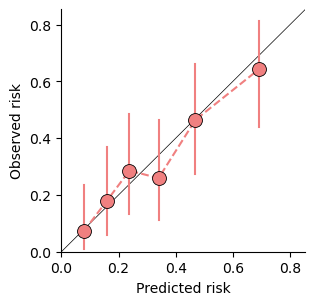

In [1]:
import matplotlib.pyplot as plt

import plot_misc.example_data.examples as examples
import plot_misc.machine_learning as ml

CMTOINCH = 1 / 2.54
# get data
data = examples.get_data("load_calibration_bins")

# using an ax object from matplotlib
fig, ax = plt.subplots(1, figsize=(8 * CMTOINCH, 8 * CMTOINCH))
cal_plot = ml.Calibration(data, ax=ax).plot(
    predicted="average_predict_risk",
    observed="average_observed_risk",
    lower_observed="lower_observed_risk",
    upper_observed="upper_observed_risk",
    line_linewidth=[1.5],
    kwargs_ci_dict={"linewidth": 1.5},
    kwargs_dot_dict={
        "s": 100,
        "edgecolor": "black",
        "linewidths": 0.6,
        "zorder": 2,
    },
)
# formatting
_ = ax.set_xlabel("Predicted risk")
_ = ax.set_ylabel("Observed risk")

## Lollipop feature-importance chart

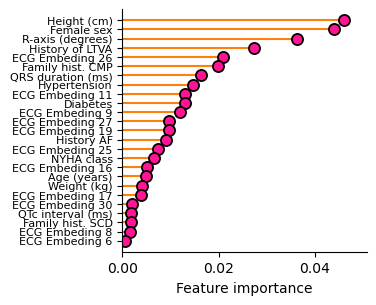

In [2]:
import matplotlib.pyplot as plt
import plot_misc.example_data.examples as examples
import plot_misc.machine_learning as ml

CMTOINCH = 1 / 2.54

# getting feature importance data
data = examples.get_data("load_lollipop_data")
data = data[data["importance"] > 0]

# plotting
fig, ax = plt.subplots(1, figsize=(8 * CMTOINCH, 8 * CMTOINCH))
_, ax = ml.lollipop(
    values=data["importance"].to_numpy(),
    labels=data["name"].to_numpy(),
    line_colour="tab:orange",
    linewidth=1.5,
    dot_color="deeppink",
    dot_edge_color="black",
    dot_size=8,
    dot_edge_size=1.3,
    reverse_feature_order=True,
    ax=ax,
)
# formatting
ax.tick_params(
    axis="y",
    labelsize=8,
)
_ = ax.set_xlabel("Feature importance")

## Net benefit (decision curve analysis)

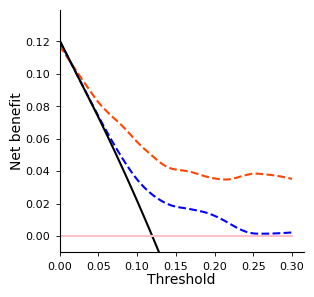

In [3]:
import numpy as np

import plot_misc.example_data.examples as examples
import plot_misc.machine_learning as ml

CMTOINCH = 1 / 2.54
M = ["DCM-PROGRESS", "maggic (3-years risk of death)", "None model", "All model"]
COL_DICT = {k: j for j, k in zip(["orangered", "blue", "pink", "black"], M)}
LINE_DICT = {k: j for j, k in zip(["--", "--", "-", "-"], M)}

# load data
data = examples.get_data("load_net_benefit_data")

# Calculating the net benefit values
nb_obj = ml.DecisionCurve(data)
nb_obj.calc_net_benefit(
    outcome="Composite outcome",
    modelnames=["DCM-PROGRESS", "maggic (3-years risk of death)"],
    thresholds=list(np.linspace(0.0, 0.3, 100)),
)

# Plotting
nb_obj.LABEL_FONT_SIZE = 10
nb_obj.TICK_LAB_SIZE = 8
_ = nb_obj.plot(
    figsize=(8 * CMTOINCH, 8 * CMTOINCH),
    col_dict=COL_DICT,
    line_dict=LINE_DICT,
    linewidth=1.5,
    kwargs_smoother={
        "it": 3,
        "frac": 1 / 3,
        "return_sorted": False,
    },
)